In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [2]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [3]:
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
df['Target'] = cali.target
print(df.shape)
df

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1:].values
print(X.shape, y.shape)

(20640, 8) (20640, 1)


In [5]:
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
X_sc

array([[ 2.34476576,  0.98214266,  0.62855945, ..., -0.04959654,
         1.05254828, -1.32783522],
       [ 2.33223796, -0.60701891,  0.32704136, ..., -0.09251223,
         1.04318455, -1.32284391],
       [ 1.7826994 ,  1.85618152,  1.15562047, ..., -0.02584253,
         1.03850269, -1.33282653],
       ...,
       [-1.14259331, -0.92485123, -0.09031802, ..., -0.0717345 ,
         1.77823747, -0.8237132 ],
       [-1.05458292, -0.84539315, -0.04021111, ..., -0.09122515,
         1.77823747, -0.87362627],
       [-0.78012947, -1.00430931, -0.07044252, ..., -0.04368215,
         1.75014627, -0.83369581]])

In [6]:
X_tensor = torch.from_numpy(X_sc).float().to(device)
y_tensor = torch.from_numpy(y).float().to(device)
print(X_tensor.shape, y_tensor.shape)

torch.Size([20640, 8]) torch.Size([20640, 1])


In [7]:
n_epochs = 100000
learning_rate = 1e-4
print_interval = 10000

In [8]:
class MyModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        super().__init__()

        self.linear1 = nn.Linear(input_dim, 7)
        self.linear2 = nn.Linear(7, 5)
        self.linear3 = nn.Linear(5, 3)
        self.linear4 = nn.Linear(3, output_dim)
        self.activation = nn.LeakyReLU()

    def forward(self, X):
        h = self.activation(self.linear1(X))
        h = self.activation(self.linear2(h))
        h = self.activation(self.linear3(h))
        y = self.linear4(h)
        return y

In [9]:
model = MyModel(X_tensor.shape[-1], y_tensor.shape[-1])
model = model.to(device)
print(model)

MyModel(
  (linear1): Linear(in_features=8, out_features=7, bias=True)
  (linear2): Linear(in_features=7, out_features=5, bias=True)
  (linear3): Linear(in_features=5, out_features=3, bias=True)
  (linear4): Linear(in_features=3, out_features=1, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
)


In [10]:
del model
torch.cuda.empty_cache()

In [11]:
model = nn.Sequential(
    nn.Linear(X_tensor.shape[-1], 7),
    nn.LeakyReLU(),
    nn.Linear(7, 5),
    nn.LeakyReLU(),
    nn.Linear(5, 3),
    nn.LeakyReLU(),
    nn.Linear(3, y_tensor.shape[-1])
)
model = model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=8, out_features=7, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=7, out_features=5, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=5, out_features=3, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=3, out_features=1, bias=True)
)


In [12]:
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
for i in range(n_epochs):
    y_hat = model(X_tensor)
    loss = F.mse_loss(y_hat, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i + 1) % print_interval == 0:
        print(f'Epoch {i + 1}: loss={loss}')

Epoch 10000: loss=0.37692686915397644
Epoch 20000: loss=0.2990659177303314
Epoch 30000: loss=0.2937580645084381
Epoch 40000: loss=0.27385395765304565
Epoch 50000: loss=0.2726161777973175
Epoch 60000: loss=0.2717418670654297
Epoch 70000: loss=0.2712871730327606
Epoch 80000: loss=0.26988914608955383
Epoch 90000: loss=0.26947271823883057
Epoch 100000: loss=0.26939648389816284


In [14]:
result_df = pd.DataFrame(torch.concat([y_hat, y_tensor], dim=1).cpu().detach_().numpy(), columns=['y_hat', 'y']).clip(lower=0, upper=5)
print(result_df.corr())
result_df

          y_hat         y
y_hat  1.000000  0.893533
y      0.893533  1.000000


,y_hat,y
0,4.256405,4.526
1,4.281048,3.585
2,4.046957,3.521
3,3.060400,3.413
4,2.572854,3.422
...,...,...
20635,0.797295,0.781
20636,0.906449,0.771
20637,0.812243,0.923
20638,0.821646,0.847


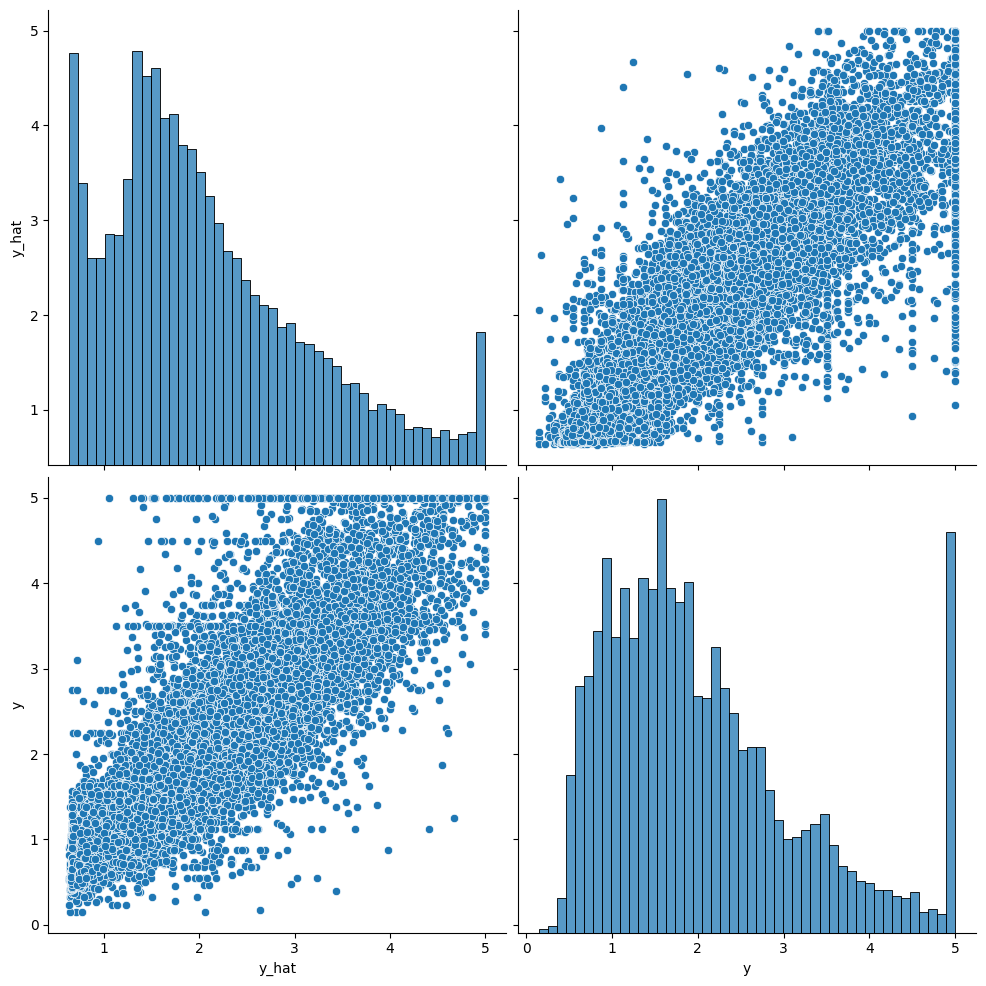

In [15]:
sns.pairplot(result_df, height=5)
plt.show()

In [16]:
del model
torch.cuda.empty_cache()